In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout
from keras.preprocessing.image import load_img
from keras.models import Sequential
from keras.utils import plot_model
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
# Ignorer les warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cellule 2 : Configuration des chemins
base_dir = '/content/drive/MyDrive/animals_dataset'
train_dir = os.path.join(base_dir, 'Train')
val_dir = os.path.join(base_dir, 'Validation')
test_dir = os.path.join(base_dir, 'Test')

In [ ]:
# Vérifier le chemin exact
!ls "/content/drive/MyDrive/animals_dataset"

 animal_classifierv1.keras		   Test
'Copie de animal_classifierv6 (1).keras'   Train
'Copie de animal_classifierv6.keras'	   Validation


In [ ]:
# Paramètres
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
SEUIL_CONFIANCE = 0.7


In [ ]:
# Cellule 3 : Data Generator avec augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Générateurs
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)
print("\n🔢 Mapping des classes :", train_generator.class_indices)

Found 13421 images belonging to 6 classes.
Found 1798 images belonging to 6 classes.
Found 1931 images belonging to 6 classes.

🔢 Mapping des classes : {'Buffalo': 0, 'chat': 1, 'chien': 2, 'elephant': 3, 'oiseau': 4, 'zebra': 5}


In [ ]:
# Cellule 4 : Construction du modèle (selon vos paramètres)
model = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPool2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPool2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPool2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPool2D(2,2),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

# Visualisation de l'architecture
plot_model(model, to_file='model_architecture.png', show_shapes=True)

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     9,437,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,700,934 (37.01 MB)

 Trainable params: 9,700,934 (37.01 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[checkpoint]
)

Epoch 1/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.3114 - loss: 1.6136
Epoch 1: val_accuracy improved from -inf to 0.60011, saving model to best_model.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 4050s 10s/step - accuracy: 0.3116 - loss: 1.6132 - val_accuracy: 0.6001 - val_loss: 1.0408
Epoch 2/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - accuracy: 0.5620 - loss: 1.1284
Epoch 2: val_accuracy improved from 0.60011 to 0.64071, saving model to best_model.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 235s 559ms/step - accuracy: 0.5620 - loss: 1.1282 - val_accuracy: 0.6407 - val_loss: 0.9362
Epoch 3/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/step - accuracy: 0.6545 - loss: 0.9114
Epoch 3: val_accuracy improved from 0.64071 to 0.72859, saving model to best_model.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 238s 568ms/step - accuracy: 0.6546 - loss: 0.9113 - val_accuracy: 0.7286 - val_loss: 0.7530
Epoch 4/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - accuracy: 0.7174 - loss: 0.7609
Epoch 4: val_accuracy imp

In [ ]:
# Sauvegarde manuelle
model.save('best_model.keras')

# Sauvegarde du modèle complet (architecture + poids + optimiseur)
model.save('complete_model.keras', save_format='keras')

In [ ]:
# Après l'entraînement ou le chargement du modèle
model.save('best_model.keras')  # Format natif Keras (recommandé)

In [ ]:
model.save('best_model.keras')
plot_model(model, to_file='model_architecture.png', show_shapes=True)

print(f"Validation Accuracy finale: {max(history.history['val_accuracy']):.2%}")

Validation Accuracy finale: 91.05%


In [ ]:
from tensorflow.keras.models import load_model

# Chargement standard
model_charge = load_model('best_model.keras')

# Chargement avec custom_objects (si nécessaire)
model_charge = load_model('best_model.keras', compile=False)

In [ ]:
import os
import tensorflow as tf

# Vérifier la taille du fichier
file_size = os.path.getsize('best_model.keras')
print(f"Taille du fichier : {file_size/1024/1024:.2f} MB")

# Vérifier l'intégrité
try:
    test_model = tf.keras.models.load_model('best_model.keras')
    print("✅ Modèle chargé avec succès")
except Exception as e:
    print(f"❌ Erreur de chargement : {e}")

Taille du fichier : 111.07 MB
✅ Modèle chargé avec succès


57/57 ━━━━━━━━━━━━━━━━━━━━ 16s 276ms/step


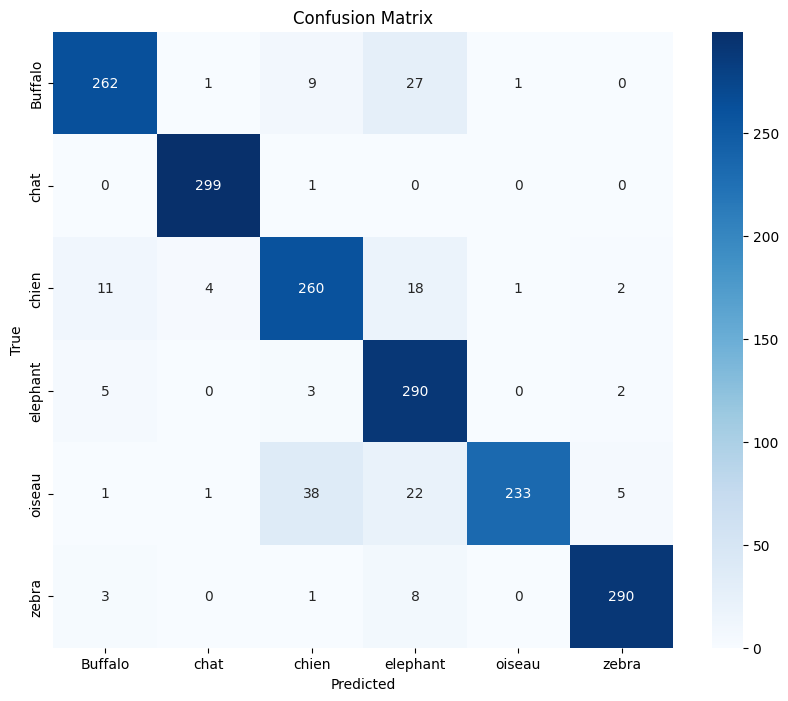

In [ ]:
SEUIL_CONFIANCE = 0.7
y_pred = np.argmax(model.predict(val_generator), axis=1)
cm = tf.math.confusion_matrix(val_generator.classes, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_generator.class_indices.keys(),
            yticklabels=train_generator.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from google.colab import files

# Sauvegarder le modèle
model.save('best_model.keras')

# Téléchargement
files.download('best_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Sauvegarde
model.save('/content/drive/MyDrive/animal_classifierv7.keras')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Cellule 7 : Sauvegarde finale
!cp model_summary.png "{save_path}"

cp: cannot stat 'model_summary.png': No such file or directory


61/61 ━━━━━━━━━━━━━━━━━━━━ 17s 268ms/step


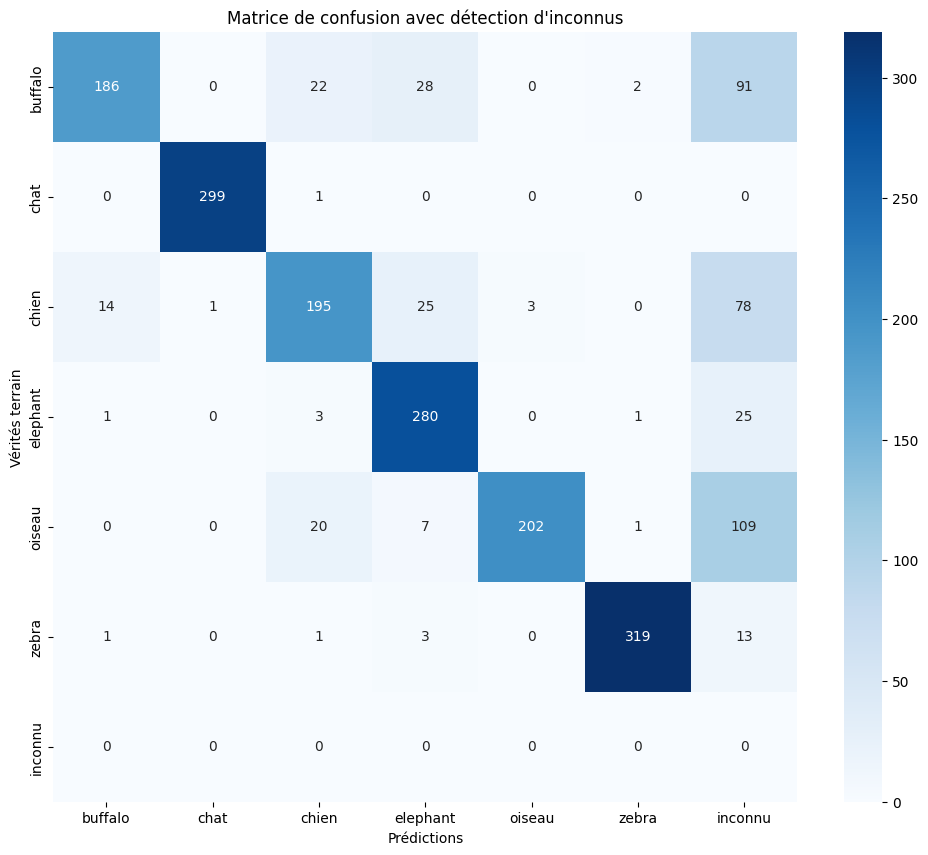

              precision    recall  f1-score   support

     buffalo       0.00      0.00      0.00         0
        chat       0.92      0.57      0.70       329
       chien       1.00      1.00      1.00       300
    elephant       0.81      0.62      0.70       316
      oiseau       0.82      0.90      0.86       310
       zebra       0.99      0.60      0.74       339
     inconnu       0.99      0.95      0.97       337

    accuracy                           0.77      1931
   macro avg       0.79      0.66      0.71      1931
weighted avg       0.92      0.77      0.83      1931



In [ ]:

model = tf.keras.models.load_model('best_model.keras')
# Prédictions avec gestion des inconnus
y_probs = model.predict(test_generator)
y_pred = np.argmax(y_probs, axis=1)
confidences = np.max(y_probs, axis=1)

# Application du seuil
unknown_mask = confidences < SEUIL_CONFIANCE
y_pred_adj = np.where(unknown_mask, -1, y_pred)

# Matrice de confusion étendue
class_names = list(test_generator.class_indices.keys()) + ['inconnu']
cm = confusion_matrix(test_generator.classes, y_pred_adj, labels=[*range(6), -1])

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Matrice de confusion avec détection d\'inconnus')
plt.xlabel('Prédictions')
plt.ylabel('Vérités terrain')
plt.savefig('confusion_matrix.png')
plt.show()

# Rapport de classification
print(classification_report(test_generator.classes, y_pred_adj, target_names=class_names))

In [ ]:
SEUIL_CONFIANCE = 0.7
def predict_image(image_path):
    img = load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)/255.
    img_array = tf.expand_dims(img_array, 0)

    pred = model.predict(img_array)
    confidence = np.max(pred)
    class_idx = np.argmax(pred)

    plt.imshow(img)

    if confidence < SEUIL_CONFIANCE:
        plt.title(f"INCONNU\nConfiance: {confidence:.2%}")
    else:
        class_name = list(train_generator.class_indices.keys())[class_idx]
        plt.title(f"{class_name}\nConfiance: {confidence:.2%}")

    plt.axis('off')
    plt.show()


In [ ]:
from google.colab import files

# Sauvegarder le modèle
model.save('animal_classifier.keras')

# Téléchargement
files.download('animal_classifier.keras')

61/61 ━━━━━━━━━━━━━━━━━━━━ 16s 257ms/step


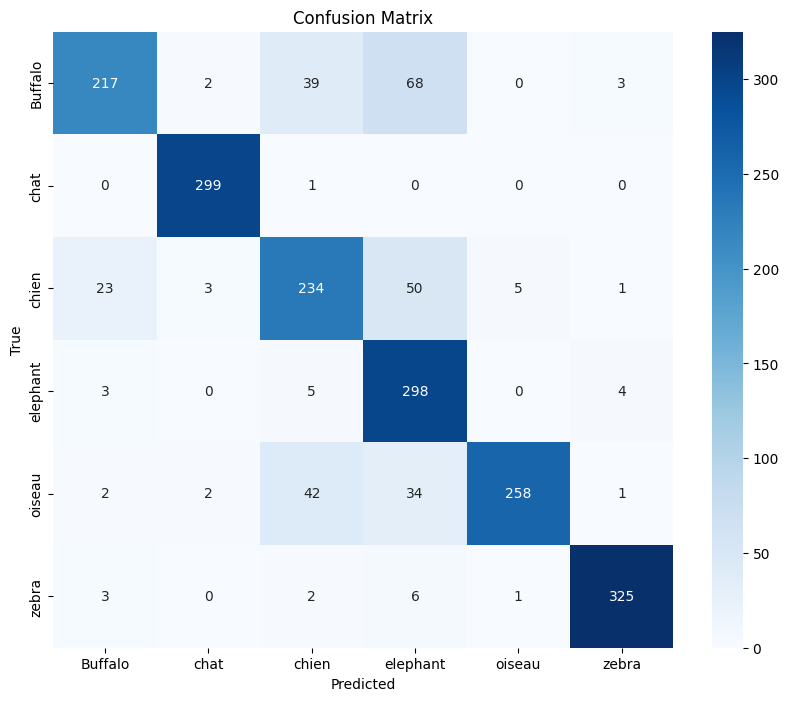

In [ ]:

y_pred = np.argmax(model.predict(test_generator), axis=1)
cm = tf.math.confusion_matrix(test_generator.classes, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_generator.class_indices.keys(),
            yticklabels=train_generator.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Saving images (8).jpg to images (8) (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


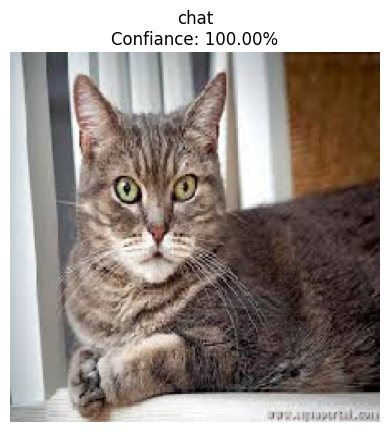

In [ ]:
# Téléverser une image
from google.colab import files
uploaded = files.upload()
for fn in uploaded.keys():
    predict_image(fn)